# 필수과제1
- 데이터셋을 드릴 예정 
- 이커머스 데이터를 통해 고객의 구매 패턴, 주기등을 파악을해서 기준을 정한다!
- 그 기준에 따라 RFM에 대한 측정 기준별 월별 지표가 만들어 질 것
- RFM 지표를 가지고 -> 세그먼트를 만들 수 있다. 
    - 방법론은 자유롭게 진행하시면 된다. 
    - kmeans 및 다른 기타 클러스터링을 진행하시면 되는데 ->내 데이터의 분포에 따른 적절한 클러스터링 작업을 해야 한다.
- 레이블이 만들어 지면
    - 레이블은 202201 ~ 202301 데이터라고 하면, 3개월 기준이라 가정하면 202204 데이터가 확보가 된다.
    - 202204 - (202201~202203의 주문데이터) 
    - 202205 - (202202~202204의 주문데이터) 
    - 202206 .. 월별 
- 월별의 레이블이 달라지게 만들어진다.
- 그 레이블의 기준으로 -> RFM 지표라 한다면 해당 지표가 어떤 식의 수렴하는 기준 값이 있는지 찾기
- 그 기준 값을 찾고 -> 해당기준 값으로 새로운 세그먼트를 만들어야 한다.
- 마지막 최종 비교는 
    - 기존 세그먼트 ( 레이블을 만든 세그먼트 )
    - 내가 인사이트를 찾아서 만든 세그먼트 
    - 둘 세그먼트의 차이를 비교분석 ( 기초통계, 카운팅 등 )
    
----
- 꼭 필요한 기준1
    - 월에 대한 데이터 기반 기준
    - 나만의 세그먼트의 RFM 지표 수렴하는 기준 
    - 세그먼트 2개의 값을 최종 비교
----
- 꼭 필요한 기준2
- 마지막 분석 코호트분석
    - 202204 기준으로 VIP라는 세그먼트의 고객들은 -> 어떤 식으로 세그먼트가 월별로 이동하는가?
    - 코호트가 어떤 식으로 세그먼트가 바뀌는지에 따른 시각화 자료

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
df = pd.read_excel("Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### 고객 구매 패턴확인 - 구매 패턴의 주기

In [3]:
# 취소반품 고객 제외 
df=df[df['UnitPrice']>0]
# 주문 취소했으니 주문 수량도 - 인 경우 제외 
df=df[df['Quantity']>0]

In [4]:
from datetime import datetime, timedelta

df['year_month'] = df['InvoiceDate'].dt.to_period('M')
df['year_week'] = df['InvoiceDate'].dt.strftime('%Y-%U')
df['weekday'] = df['InvoiceDate'].dt.dayofweek
weekday_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# 전체집계
total_monthly = df.groupby('year_month').size().reset_index(name = 'total_orders')
total_weekly = df.groupby('year_week').size().reset_index(name = 'total_orders')
weekday_counts = df.groupby('weekday').size().reindex(range(7), fill_value = 0).reset_index(name = 'total_orders')
weekday_counts['weekday_label'] = weekday_labels

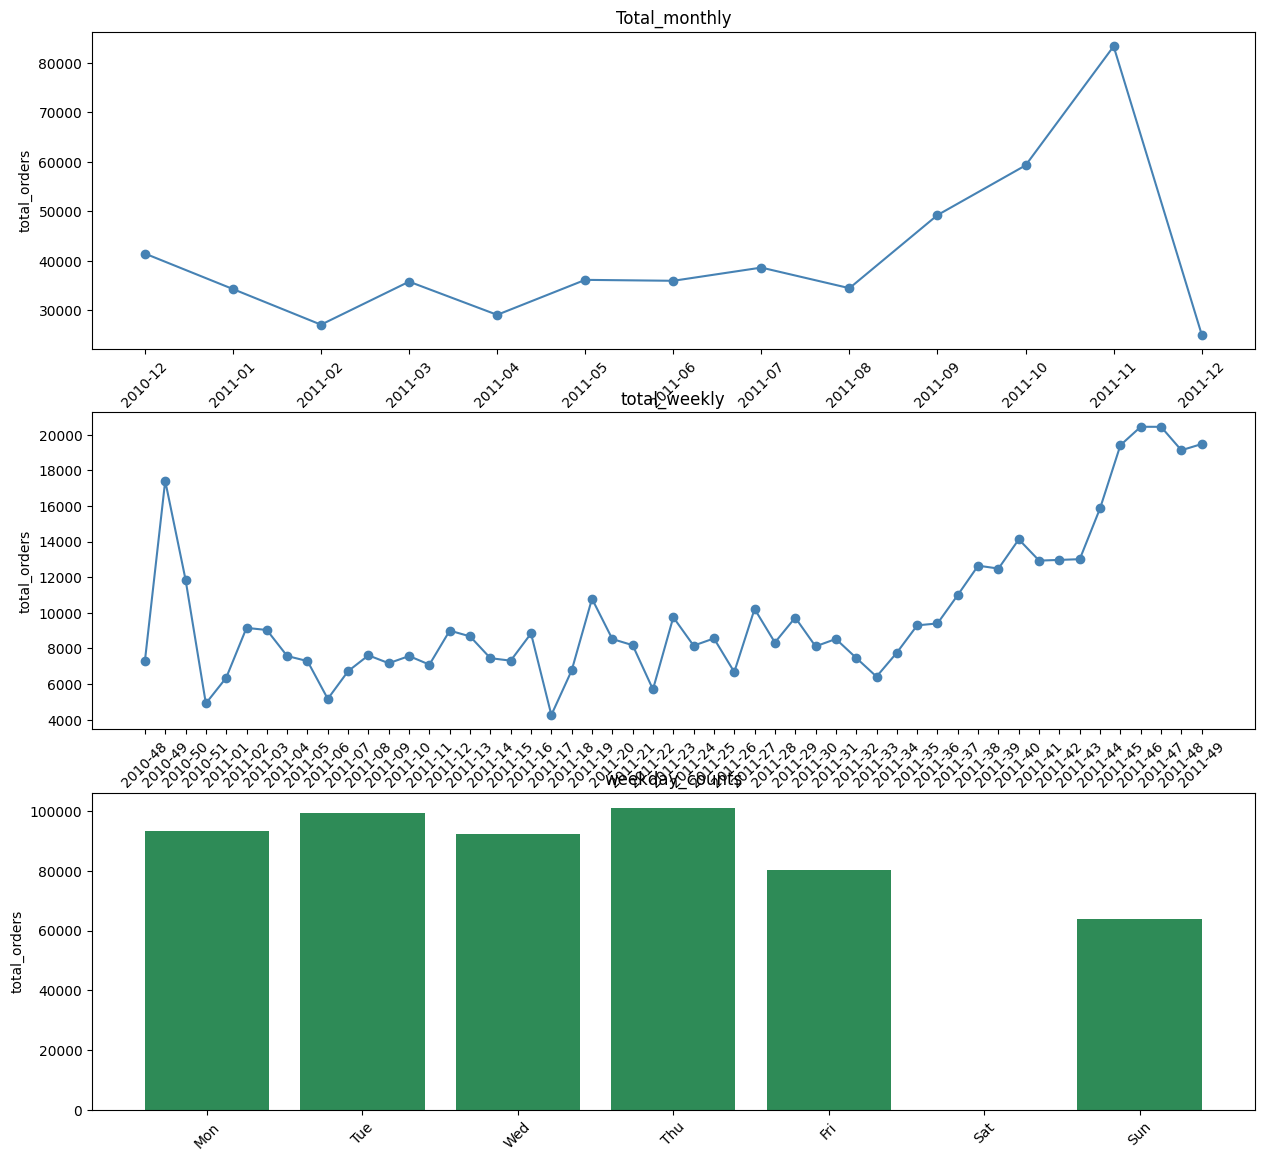

In [5]:
fig, axes = plt.subplots(3,1, figsize=(15,14))

##월별 트렌드

axes[0].plot(total_monthly['year_month'].astype(str), total_monthly['total_orders'], marker='o',color='steelblue')
axes[0].set_title('Total_monthly')
axes[0].set_ylabel('total_orders')
axes[0].tick_params(axis='x', rotation=45)


# 주별 트렌드
axes[1].plot(total_weekly['year_week'].astype(str), total_weekly['total_orders'], marker='o',color='steelblue')
axes[1].set_title('total_weekly')
axes[1].set_ylabel('total_orders')
axes[1].tick_params(axis='x', rotation=45)

# 요일별 트렌드
axes[2].bar(weekday_counts['weekday_label'].astype(str), weekday_counts['total_orders'],color='seagreen')
axes[2].set_title('weekday_counts')
axes[2].set_ylabel('total_orders')
axes[2].tick_params(axis='x', rotation=45)

In [6]:
total_monthly

,year_month,total_orders
0,2010-12,41480
1,2011-01,34306
2,2011-02,27105
3,2011-03,35803
4,2011-04,29096
5,2011-05,36164
6,2011-06,35977
7,2011-07,38645
8,2011-08,34483
9,2011-09,49261


In [7]:
total_weekly

,year_week,total_orders
0,2010-48,7290
1,2010-49,17407
2,2010-50,11869
3,2010-51,4914
4,2011-01,6353
5,2011-02,9153
6,2011-03,9037
7,2011-04,7576
8,2011-05,7291
9,2011-06,5171


In [8]:
weekday_counts

,weekday,total_orders,weekday_label
0,0,93136,Mon
1,1,99460,Tue
2,2,92315,Wed
3,3,101007,Thu
4,4,80281,Fri
5,5,0,Sat
6,6,63905,Sun


### RFM분석

In [37]:
from datetime import timedelta

## 기준일 설정 가장 마지막일 주문 +1 기준으로 본다 (오늘기준)
snapshot_date=df['InvoiceDate'].max() + timedelta(days=1)

###rfm 계산

rfm=df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x :(snapshot_date -x.max()).days,
    'CustomerID':'count', # 주문번호가 만들지 않아서 이번에는 customer_id로 하는 것
    'Quantity' :'sum'    
}).rename(columns = {
    'InvoiceDate':'Recency',
    'CustomerID':'Frequency',
    'Quantity':'Monetary'
}).reset_index()

In [38]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0
1,12347.0,2,182,2458
2,12348.0,75,31,2341
3,12349.0,19,73,631
4,12350.0,310,17,197
...,...,...,...,...
4367,18280.0,278,10,45
4368,18281.0,181,7,54
4369,18282.0,8,13,98
4370,18283.0,4,756,1397


Text(0.5, 0, 'Purchase')

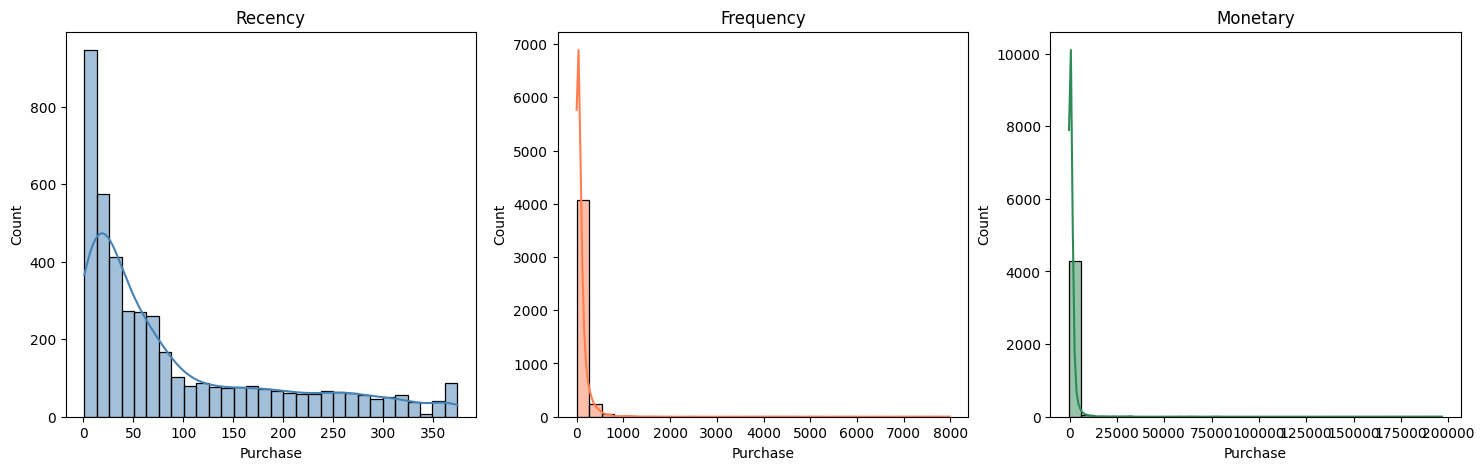

In [39]:
## rfm의 수치에 대한 주기는 월별 기준에 따라 달라진다.
import seaborn as sns

plt.figure(figsize=(18,5))

##Recency
plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins = 30, kde=True, color='steelblue')
plt.title('Recency')
plt.xlabel('Purchase')

##Recency
plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins = 30, kde=True, color='coral')
plt.title('Frequency')
plt.xlabel('Purchase')

##Recency
plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins = 30, kde=True, color='seagreen')
plt.title('Monetary')
plt.xlabel('Purchase')

In [40]:
## 통계적인 분포 모형 불러오기

from scipy.stats import expon, poisson, gamma

## 평균의 기반으로 파라미터 추정 
labmda_r=1/rfm['Recency'].mean()
mu_f=rfm['Frequency'].mean()
rfm_clean = rfm[rfm['Monetary'] > 0]
a_m, loc_m, scale_m = gamma.fit(rfm_clean['Monetary'], floc=0)

## 확률을 계산해 보자!

rfm['recency_prob']=expon.cdf(rfm['Recency'], scale=1/ labmda_r)
rfm['frequency_prob']= poisson.pmf(rfm['Frequency'], mu=mu_f)
rfm['monetary_prob']= gamma.cdf(rfm['Monetary'], a=a_m, loc= loc_m, scale =scale_m)

In [41]:
rfm

,CustomerID,Recency,Frequency,Monetary,recency_prob,frequency_prob,monetary_prob
0,12346.0,326,2,0,0.971035,1.674563e-37,0.000000
1,12347.0,2,182,2458,0.021494,1.191037e-16,0.862222
2,12348.0,75,31,2341,0.557272,5.048130e-14,0.851724
3,12349.0,19,73,631,0.186505,4.514057e-03,0.518649
4,12350.0,310,17,197,0.965536,3.197711e-22,0.284906
...,...,...,...,...,...,...,...
4367,18280.0,278,10,45,0.951208,5.188269e-28,0.124246
4368,18281.0,181,7,54,0.860038,4.636174e-31,0.137900
4369,18282.0,8,13,98,0.083242,2.436130e-25,0.193383
4370,18283.0,4,756,1397,0.042525,0.000000e+00,0.725317


In [42]:
a_m

0.5811079105283534

In [43]:
mu_f

np.float64(93.05329368709972)

In [44]:
scale_m

np.float64(1955.8092647650935)

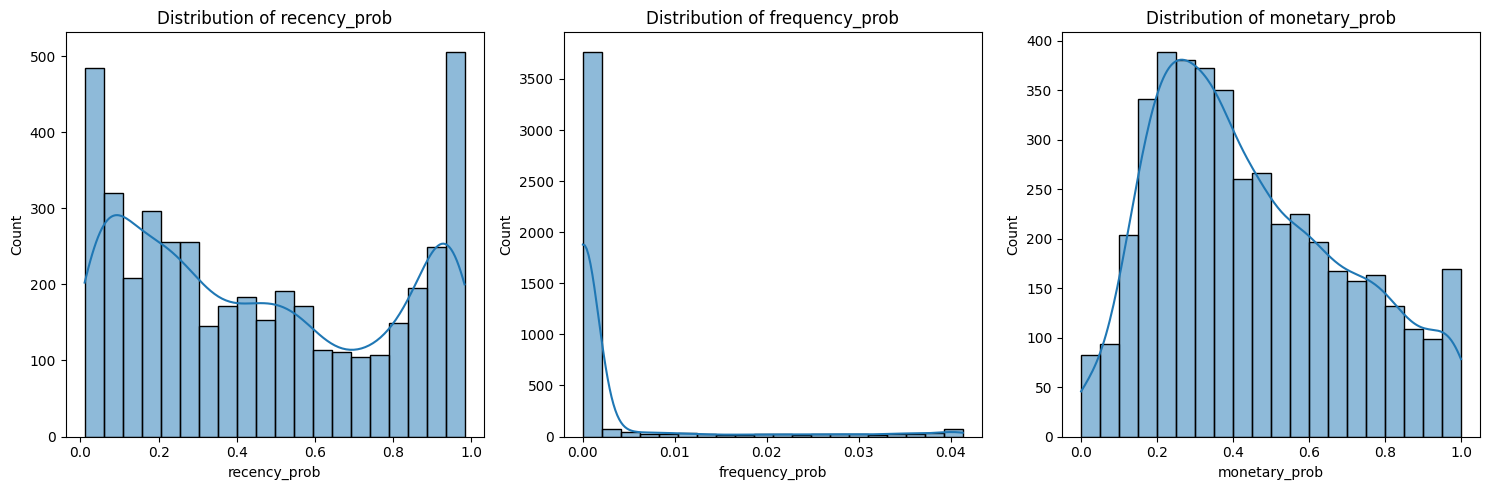

   CustomerID  Recency  Frequency  Monetary  recency_prob  frequency_prob  \
0     12346.0      326          2         0      0.971035    1.674563e-37   
1     12347.0        2        182      2458      0.021494    1.191037e-16   
2     12348.0       75         31      2341      0.557272    5.048130e-14   
3     12349.0       19         73       631      0.186505    4.514057e-03   
4     12350.0      310         17       197      0.965536    3.197711e-22   
5     12352.0       36         95       470      0.323690    4.007604e-02   
6     12353.0      204          4        20      0.890984    1.208325e-34   
7     12354.0      232         58       530      0.919576    2.527772e-05   
8     12355.0      214         13       240      0.902206    2.436130e-25   
9     12356.0       23         59      1591      0.221100    3.986738e-05   

   monetary_prob R_Segment F_Segment M_Segment     RFM_Segment  
0       0.000000       Low       Low       Low     Low-Low-Low  
1       0.862222      

In [46]:
# 5. 확률 분포 시각화 (각 변수의 분포 확인)
plt.figure(figsize=(15, 5))
for i, col in enumerate(['recency_prob', 'frequency_prob', 'monetary_prob']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(rfm[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 6. 분위수 기반 세그먼트 나누기 (Low, Mid, High)
def segment_by_quantile(series):
    return pd.qcut(series, q=3, labels=['Low', 'Mid', 'High'])

# Recency는 값이 작을수록 최근 방문 → 1 - prob 사용
rfm['R_Segment'] = segment_by_quantile(1 - rfm['recency_prob'])  # 작을수록 좋은 고객
rfm['F_Segment'] = segment_by_quantile(rfm['frequency_prob'])    # 확률 높을수록 일반적인 빈도
rfm['M_Segment'] = segment_by_quantile(rfm['monetary_prob'])     # 금액 높을수록 좋음

# 7. 세그먼트 조합 생성 (ex: High-Mid-Low)
rfm['RFM_Segment'] = (
    rfm['R_Segment'].astype(str) + '-' +
    rfm['F_Segment'].astype(str) + '-' +
    rfm['M_Segment'].astype(str)
)

# 8. 결과 출력 (필요 컬럼만 보기 좋게 정리)
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
           'recency_prob', 'frequency_prob', 'monetary_prob',
           'R_Segment', 'F_Segment', 'M_Segment', 'RFM_Segment']].head(10))

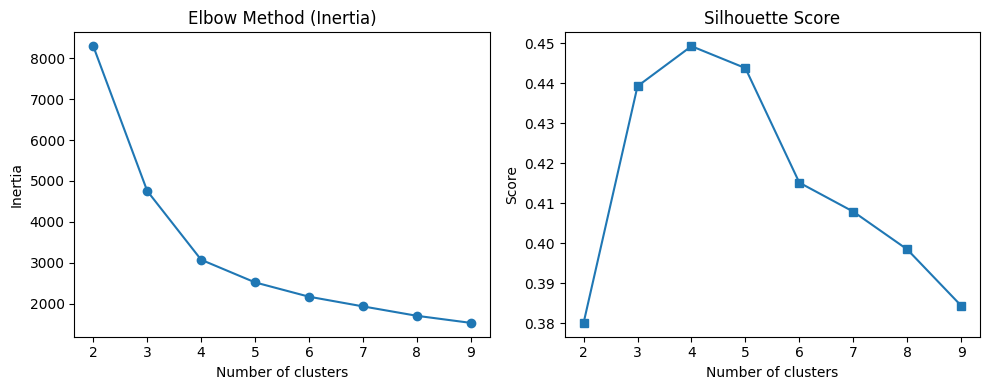

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 5. 클러스터링에 사용할 입력 변수 추출
X = rfm[['recency_prob', 'frequency_prob', 'monetary_prob']]

# 6. 스케일링 (K-Means는 거리 기반 → 스케일 표준화 필요)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. 최적 클러스터 수 결정 (Elbow method + Silhouette score)
inertia = []
silhouette = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# 8. Elbow plot으로 최적 군집 수 시각화
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(2, 10), inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), silhouette, marker='s')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

         recency_prob  frequency_prob  monetary_prob
Cluster                                             
0            0.851457        0.000269       0.274899
1            0.217298        0.001060       0.777991
2            0.343810        0.031906       0.563820
3            0.291887        0.000436       0.338579


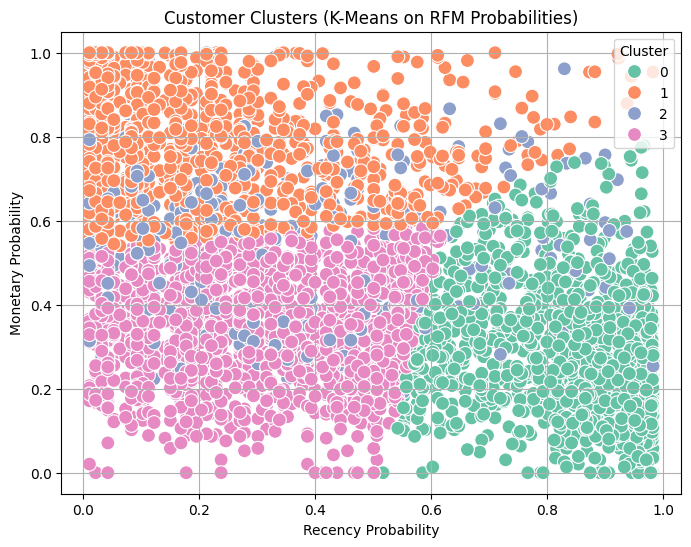

In [48]:
# 9. K-Means 모델 훈련 (예: k=4)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 10. 결과 확인 (클러스터별 특성 평균 보기)
cluster_summary = rfm.groupby('Cluster')[['recency_prob', 'frequency_prob', 'monetary_prob']].mean()
print(cluster_summary)

# 11. 시각화 (예: 2D scatter)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='recency_prob', y='monetary_prob',
    hue='Cluster', data=rfm, palette='Set2', s=100
)
plt.title('Customer Clusters (K-Means on RFM Probabilities)')
plt.xlabel('Recency Probability')
plt.ylabel('Monetary Probability')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [49]:
# 1. 클러스터링 기반으로 분류된 고객 데이터에서 Cluster 컬럼이 있다고 가정
# (이미 KMeans로 rfm['Cluster'] 생성된 상태)

# 2. 클러스터별 R, F, M 값에 대한 통계량 집계
rfm_cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max', 'std','count']
).round(2)

# 3. 결과 출력
print("클러스터별 RFM 기초 통계 요약:\n")
print(rfm_cluster_summary)

클러스터별 RFM 기초 통계 요약:

        Recency                              Frequency                   \
           mean median min  max    std count      mean median min   max   
Cluster                                                                   
0        210.59  203.0  67  374  86.10  1441     28.23   19.0   1   548   
1         27.25   16.0   1  372  34.27  1119    239.85  158.0   1  7983   
2         52.29   30.0   1  374  61.32   333     92.39   92.0  80   106   
3         34.53   31.0   1   89  22.94  1479     45.30   32.0   1   354   

                      Monetary                                      
            std count     mean  median  min     max      std count  
Cluster                                                             
0         35.42  1441   235.62   158.0 -303    1722   241.60  1441  
1        420.44  1119  3374.78  1673.0  671  196719  8811.99  1119  
2          7.36   333   999.62   810.0   97   23377  1446.08   333  
3         46.72  1479   309.73   274.0 

### 코호트 분석

In [50]:
# InvoiceDate를 datetime으로 변환
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 월 단위로 변환
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 고객별 최초 구매월 → 코호트 기준
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

In [51]:
def get_cohort_index(row):
    year_diff = row['InvoiceMonth'].year - row['CohortMonth'].year
    month_diff = row['InvoiceMonth'].month - row['CohortMonth'].month
    return year_diff * 12 + month_diff + 1

df['CohortIndex'] = df.apply(get_cohort_index, axis=1)

In [52]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

In [53]:
cohort_sizes = cohort_counts.iloc[:, 0]  # 첫 달 기준 인원
retention = cohort_counts.divide(cohort_sizes, axis=0)

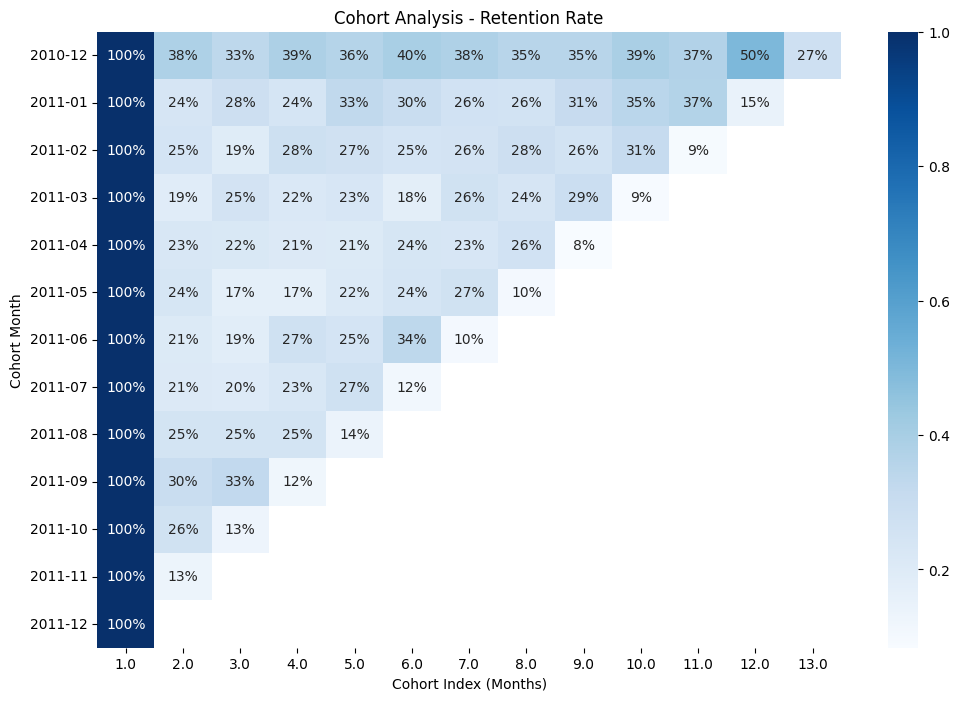

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title('Cohort Analysis - Retention Rate')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months)')
plt.show()


### LTV

In [55]:
import pandas as pd
import numpy as np

# 1. 데이터 로딩 및 전처리
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# 2. 기준 구간 분리
baseline_df = df[(df['InvoiceDate'] >= '2011-01-01') & (df['InvoiceDate'] < '2011-04-01')]
future_df = df[(df['InvoiceDate'] >= '2011-04-01') & (df['InvoiceDate'] < '2011-07-01')]

In [58]:
# 3. RFM 계산 (기준 기간만 사용)
snapshot_date = baseline_df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = baseline_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'CustomerID': 'nunique',
    'Quantity': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'CustomerID': 'Frequency',
    'Quantity': 'Monetary'
})

# 4. LTV 예측 모델 (예시: Frequency × Monetary / 기간)
# 단순 예: LTV = 평균 구매 금액 * 구매 주기 * 예상 기간(3개월)
rfm['LTV_pred'] = (rfm['Monetary'] / rfm['Frequency']) * (rfm['Frequency'] / 3)  # 월 평균 × 3개월

In [60]:
# 5. 실제 3개월 구매금액 집계
actual_ltv = future_df.groupby('CustomerID')['Quantity'].sum().rename('LTV_actual')

# 6. 병합 후 오차 계산
result = rfm[['LTV_pred']].join(actual_ltv, how='left').fillna(0)
result['Error'] = result['LTV_actual'] - result['LTV_pred']
result['AbsoluteError'] = result['Error'].abs()

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(result['LTV_actual'], result['LTV_pred'])
rmse = np.sqrt(mean_squared_error(result['LTV_actual'], result['LTV_pred']))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 321.66, RMSE: 1188.91
